In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Datos numéricos
P = 5.0  # Periodo típico en DÍAS
omega_0 = 2 * np.pi / P  # Frecuencia natural en rad/día
xi = 0.1
R_sol = 7e8
R_0 = 42.7 * R_sol
x_0 = 0.01 * R_0
v_0 = 0.0

#Parámetros de integración RK4
h = 0.01  # Tamaño de paso en DÍAS
t_final = 50.0  # 50 días
n_pasos = int(t_final / h)  

print(f"Frecuencia natural omega_0: {omega_0:.6e} rad/s")
print(f"Radio medio R_0: {R_0:.6e} m")
print(f"Desplazamiento inicial x_0: {x_0:.6e} m")

Frecuencia natural omega_0: 1.256637e+00 rad/s
Radio medio R_0: 2.989000e+10 m
Desplazamiento inicial x_0: 2.989000e+08 m


In [3]:
# (a) Transformar el sistema de orden 2 a 2-ODEs de orden 1
# Sea x1 = x  y  x2 = v = dx/dt
# Entonces:
# dx1/dt = x2
# dx2/dt = -omega_0^2 * x1 - omega_0 * xi * x2

#Implementación de Eliminación Gaussiana con Pivoteo Parcial ---
# Matriz A (2x2) para el sistema de estado: [dx1/dt, dx2/dt]^T = A * [x1, x2]^T
# A = [[0, 1], [-omega_0^2, -omega_0 * xi]]
A = np.array([[0.0, 1.0], 
              [-omega_0**2, -omega_0 * xi]])

b = np.array([0.0, 0.0])  # No hay términos constantes en la ODE

#  Eliminación Gaussiana con Pivoteo Parcial
if abs(A[1, 0]) > abs(A[0, 0]):
    # Intercambiar filas
    A[[0, 1]] = A[[1, 0]]
    b[[0, 1]] = b[[1, 0]]

factor = A[1, 0] / A[0, 0]
A[1, 0] = A[1, 0] - factor * A[0, 0]
A[1, 1] = A[1, 1] - factor * A[0, 1]
b[1] = b[1] - factor * b[0]

x2_sol = b[1] / A[1, 1]
x1_sol = (b[0] - A[0, 1] * x2_sol) / A[0, 0]

print("Matriz A después de eliminación gaussiana:")
print(A)
print(f"Solución del sistema lineal: x1 = {x1_sol}, x2 = {x2_sol}")

Matriz A después de eliminación gaussiana:
[[-1.5791367  -0.12566371]
 [ 0.          1.        ]]
Solución del sistema lineal: x1 = -0.0, x2 = 0.0


In [4]:
# (b) Resolver usando RK4 con h = 0.01
t = np.zeros(n_pasos + 1)
x = np.zeros(n_pasos + 1)
v = np.zeros(n_pasos + 1)

# Condiciones iniciales
t[0] = 0.0
x[0] = x_0
v[0] = v_0

# Integración RK4
for i in range(n_pasos):
    # Valores actuales
    t_actual = t[i]
    x_actual = x[i]
    v_actual = v[i]
    
    #K1 
    k1_x = v_actual
    k1_v = -omega_0**2 * x_actual - omega_0 * xi * v_actual
    
    #K2
    x_k2 = x_actual + 0.5 * h * k1_x
    v_k2 = v_actual + 0.5 * h * k1_v
    k2_x = v_k2
    k2_v = -omega_0**2 * x_k2 - omega_0 * xi * v_k2
    
    #K3
    x_k3 = x_actual + 0.5 * h * k2_x
    v_k3 = v_actual + 0.5 * h * k2_v
    k3_x = v_k3
    k3_v = -omega_0**2 * x_k3 - omega_0 * xi * v_k3
    
    #K4
    x_k4 = x_actual + h * k3_x
    v_k4 = v_actual + h * k3_v
    k4_x = v_k4
    k4_v = -omega_0**2 * x_k4 - omega_0 * xi * v_k4
    
    #Actualización de estado
    x[i+1] = x_actual + (h/6.0) * (k1_x + 2*k2_x + 2*k3_x + k4_x)
    v[i+1] = v_actual + (h/6.0) * (k1_v + 2*k2_v + 2*k3_v + k4_v)
    t[i+1] = t_actual + h

print("Integración RK4 completada.")

Integración RK4 completada.


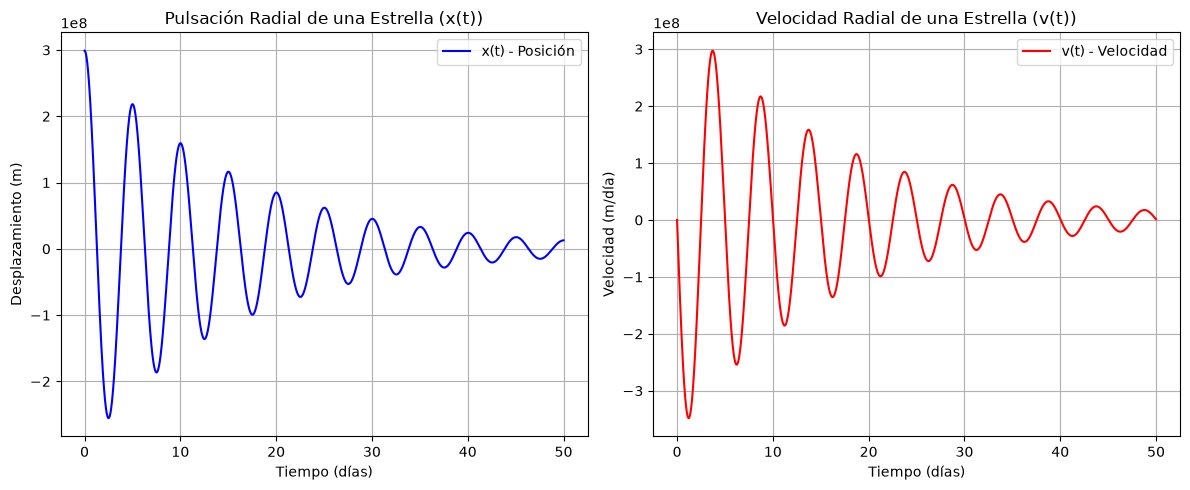

Gráficas generadas


In [7]:
# (c) Graficar x(t) y v(t) 
plt.figure(figsize=(12, 5))

# Gráfica de posición x(t)
plt.subplot(1, 2, 1)
plt.plot(t, x, color='blue', label='x(t) - Posición')
plt.title('Pulsación Radial de una Estrella (x(t))')
plt.xlabel('Tiempo (días)')
plt.ylabel('Desplazamiento (m)')
plt.grid(True)
plt.legend()

# Gráfica de velocidad v(t)
plt.subplot(1, 2, 2)
plt.plot(t, v, color='red', label='v(t) - Velocidad')
plt.title('Velocidad Radial de una Estrella (v(t))')
plt.xlabel('Tiempo (días)')
plt.ylabel('Velocidad (m/día)')  # <-- CORREGIDO: Ahora dice m/día
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print("Gráficas generadas")